In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import colormaps
from matplotlib.ticker import LogFormatterMathtext
import matplotlib.colors as mcolors
import matplotlib.animation as animation
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import FancyArrowPatch
import plotly.graph_objects as go

In [ ]:
# Display interactive plots embedded within the notebook
# %matplotlib inline
# %matplotlib ipympl
%matplotlib widget

# Unit conversion
def cm2inch(cm):
    """Centimeters to inches"""
    return cm/2.54

# To display a number in scientific notation inside a LaTeX math expression
def sci_latex(num):
    mantissa, exponent = f"{num:.1e}".split("e")
    return fr'{mantissa} \times 10^{{{int(exponent)}}}'

# def arrowhead(ax, traj, d, c, hw=1.25, hl=1.50, alpha=1.0, zorder=5):
#     """
#     Place a single arrow at distance d (arc length) from the start of traj.
#     """
#     # segment lengths and cumulative arc length
#     diffs       = np.diff(traj, axis=0)
#     seg_lengths = np.sqrt((diffs**2).sum(axis=1))
#     arc_len     = np.concatenate(([0], np.cumsum(seg_lengths)))

#     if d > arc_len[-1]:
#         return  # trajectory too short, skip

#     # interpolate position
#     x = np.interp(d, arc_len, traj[:,0])
#     y = np.interp(d, arc_len, traj[:,1])

#     # interpolate tangent direction for arrow orientation
#     idx    = np.searchsorted(arc_len, d) - 1 + 1
#     dx, dy = diffs[idx]
#     norm   = np.sqrt(dx**2 + dy**2)
#     dx, dy = dx/norm, dy/norm

#     ax.arrow(x, y, dx*0.5, dy*0.5, head_width=hw, head_length=hl, fc=c, ec=c, lw=0, alpha=alpha, length_includes_head=True, zorder=zorder)

def arrowhead(ax, traj, d, c, hw=1.25, hl=1.50, alpha=1.0, zorder=5):
    """
    Place a single arrow at distance d (arc length) from the start of traj.
    """
    # segment lengths and cumulative arc length
    diffs = np.diff(traj, axis=0)
    if len(diffs) == 0:
        return

    seg_lengths = np.sqrt((diffs**2).sum(axis=1))
    arc_len = np.concatenate(([0], np.cumsum(seg_lengths)))

    if d > arc_len[-1]:
        return
    
    # interpolate position
    x = np.interp(d, arc_len, traj[:,0])
    y = np.interp(d, arc_len, traj[:,1])

    # interpolate tangent direction for arrow orientation
    idx = np.searchsorted(arc_len, d) - 1
    idx = np.clip(idx, 0, len(diffs)-1)
    dx, dy = diffs[idx]
    norm = np.sqrt(dx**2 + dy**2)

    if norm == 0:
        return

    dx, dy = dx/norm, dy/norm

    arrow = FancyArrowPatch((x, y), (x + dx*0.5, y + dy*0.5), arrowstyle='-|>', mutation_scale=10*hl, color=c, lw=0, alpha=alpha, zorder=zorder)

    ax.add_patch(arrow)

In [4]:
# Thicker axes
plt.rc('axes', linewidth=1)

# Use LaTeX for text rendering with default LaTeX math font (Computer Modern)
plt.rc('text', usetex=True)
plt.rc('font', size=10, family='serif', serif=['Computer Modern'])

# Ticks and labels parameters
label_size = 10
plt.rcParams['xtick.labelsize'] = label_size
plt.rcParams['ytick.labelsize'] = label_size

## Multiple trajectories

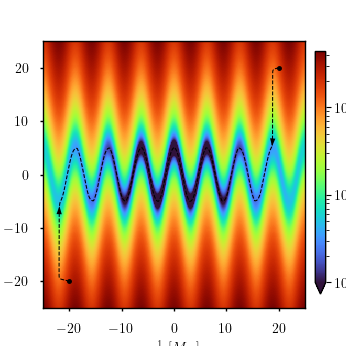

In [ ]:
#  Potential colormap and trajectories for non-linear potential

# Parameters
phi1_min, phi1_max = -25, 25
phi2_min, phi2_max = -25, 25
width              = 8.8
aspect             = 1
colormap           = "turbo"
ntrajs             = 8

# Load data
potential = np.loadtxt(f'potential_DEP.txt')
ngrid = potential.shape[0]

# Coordinate axes
phi1   = np.linspace(phi1_min, phi1_max, ngrid)
phi2   = np.linspace(phi2_min, phi2_max, ngrid)
extent = [phi1_min, phi1_max, phi2_min, phi2_max]

# Create figure and axis
fig, ax = plt.subplots(figsize=(cm2inch(width), cm2inch(width/aspect)))

# Plot
im = ax.imshow(potential, origin='lower', extent=extent, aspect='auto', cmap=colormap, interpolation='none', norm=mcolors.LogNorm(vmin=1E-10), alpha=1.0)
# im = ax.imshow(potential, origin='lower', extent=extent, aspect='auto', cmap=colormap, interpolation='none', vmin=-11, vmax=-8)

# Tell Matplotlib not to epand the data limits when drawing arrows
ax.autoscale(False)

# Plot trajectories
for i in [1,8]:
    traj = np.loadtxt(f"trajs_EUM_DEP/traj_{i}.txt")
    plt.plot(traj[:, 0], traj[:, 1], linestyle='--', color='black', lw=0.75, alpha=1.0)
    plt.plot(traj[0, 0], traj[0, 1], 'o', color='black', markersize=2.5, alpha=1.0)
    arrowhead(ax, traj[: , :2], d=15.0, hw=1.0, hl=1.5)

# Plot trajectories
# for i in range(1, ntrajs+1):
# for i in [1,3,6,8]:
#     traj = np.loadtxt(f"trajs_OWM_NLP/traj_{i}.txt")
#     plt.plot(traj[:, 0], traj[:, 1], linestyle='-', color='black', lw=0.75, alpha=0.75)
#     plt.plot(traj[0, 0], traj[0, 1], 'o', color='black', markersize=2.5, alpha=1.0)
#     arrowhead(ax, traj[: , :2], d=18.0, hw=1.0, hl=1.5)

# Axis formatting
# ax.set_title(fr'$\alpha = \beta = 1$', fontsize=10)
ax.set_xlabel(r'$\varphi^1 ~ [M_{\mathrm{Pl}}]$', fontsize=10)
ax.set_ylabel(r'$\varphi^2 ~ [M_{\mathrm{Pl}}]$', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=10, length=2.5, width=1, pad=8)

# Colorbar with separate axis
cbar_ax = fig.add_axes([0.91, 0.15, 0.03, 0.7]) # [left, bottom, width, height] in figure coords
# cbar    = fig.colorbar(im, cax=cbar_ax, extend="max")
cbar    = fig.colorbar(im, cax=cbar_ax, extend="min")
cbar.set_label(r'$V(\varphi) ~ [M_{\mathrm{Pl}}^{4}]$', fontsize=10)
cbar.ax.tick_params(labelsize=10)


# Leave space for colorbar
plt.subplots_adjust(right=0.88)

# Save
plt.savefig(f'trajs_4IC_EUM_DEP.pdf', bbox_inches='tight')

## Single Trajectory

TypeError: arrowhead() missing 1 required positional argument: 'c'

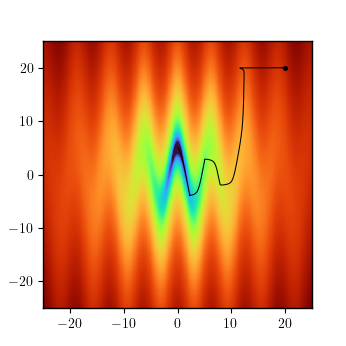

In [387]:
#  Potential colormap and trajectories for non-linear potential

# Parameters
phi1_min, phi1_max = -25, 25
phi2_min, phi2_max = -25, 25
width              = 8.8
aspect             = 1
colormap           = "turbo"
ntrajs             = 8

# Load data
potential = np.loadtxt(f'potential_DEP.txt')
ngrid = potential.shape[0]

# Coordinate axes
phi1   = np.linspace(phi1_min, phi1_max, ngrid)
phi2   = np.linspace(phi2_min, phi2_max, ngrid)
extent = [phi1_min, phi1_max, phi2_min, phi2_max]

# Create figure and axis
fig, ax = plt.subplots(figsize=(cm2inch(width), cm2inch(width/aspect)))

# Plot
im = ax.imshow(potential, origin='lower', extent=extent, aspect='auto', cmap=colormap, interpolation='none', norm=mcolors.LogNorm(vmin=1E-12), alpha=1.0)
# im = ax.imshow(potential, origin='lower', extent=extent, aspect='auto', cmap=colormap, interpolation='none', vmin=-11, vmax=-8)

# Tell Matplotlib not to epand the data limits when drawing arrows
ax.autoscale(False)

# Plot trajectories
traj = np.loadtxt(f"traj_EUM_DEP/traj.txt")
plt.plot(traj[:, 0], traj[:, 1], linestyle='-', color='black', lw=0.75, alpha=1.0)
plt.plot(traj[0, 0], traj[0, 1], 'o', color='black', markersize=2.5, alpha=1.0)
arrowhead(ax, traj[: , :2], d=15.0, hw=1.0, hl=1.5)

# Plot trajectories
traj = np.loadtxt(f"traj_EUM_DEP/traj_v0.txt")
plt.plot(traj[:, 0], traj[:, 1], linestyle='--', color='black', lw=0.75, alpha=1.0)
plt.plot(traj[0, 0], traj[0, 1], 'o', color='black', markersize=2.5, alpha=1.0)
arrowhead(ax, traj[: , :2], d=15.0, hw=1.0, hl=1.5)

# Axis formatting
# ax.set_title(fr'$\alpha = \beta = 1$', fontsize=10)
ax.set_xlabel(r'$\varphi^1 ~ [M_{\mathrm{Pl}}]$', fontsize=10)
ax.set_ylabel(r'$\varphi^2 ~ [M_{\mathrm{Pl}}]$', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=10, length=2.5, width=1, pad=8)

# Colorbar with separate axis
cbar_ax = fig.add_axes([0.91, 0.15, 0.03, 0.7]) # [left, bottom, width, height] in figure coords
# cbar    = fig.colorbar(im, cax=cbar_ax, extend="max")
cbar    = fig.colorbar(im, cax=cbar_ax, extend="min")
cbar.set_label(r'$V(\varphi) ~ [M_{\mathrm{Pl}}^{4}]$', fontsize=10)
cbar.ax.tick_params(labelsize=10)


# Leave space for colorbar
plt.subplots_adjust(right=0.88)

# Save
plt.savefig(f'trajs_1IC_EUM_DEP.pdf', bbox_inches='tight')

## Gaussian bumps metric with non-linear potential

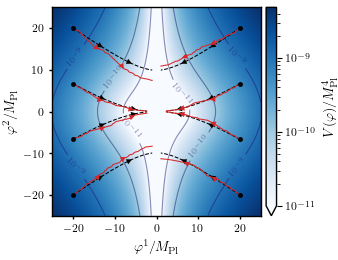

In [598]:
#  Potential colormap and trajectories for non-linear potential

# Parameters
phi1_min, phi1_max = -25, 25
phi2_min, phi2_max = -25, 25
width              = 8.6
aspect             = 1.3
colormap           = "Blues"
ntrajs             = 8

# Load data
potential = np.loadtxt(f'potential_NLP.txt')
ngrid = potential.shape[0]

# Coordinate axes
phi1   = np.linspace(phi1_min, phi1_max, ngrid)
phi2   = np.linspace(phi2_min, phi2_max, ngrid)
extent = [phi1_min, phi1_max, phi2_min, phi2_max]

# Create figure
fig = plt.figure(figsize=(cm2inch(width), cm2inch(width/aspect)))
ax = fig.add_axes([0.05, 0.17, 0.80, 0.80])  # [left, bottom, width, height]
ax.set_box_aspect(1)

# Plot
im = ax.imshow(potential, origin='lower', extent=extent, aspect='auto', cmap=colormap, interpolation='none', norm=mcolors.LogNorm(vmin=1E-11), alpha=1.0)
# im = ax.imshow(potential*1E9, origin='lower', extent=extent, aspect='auto', cmap=colormap, interpolation='none')

# Tell Matplotlib not to epand the data limits when drawing arrows
ax.autoscale(False)

# Contour lines parameters
V = potential

nlevels = 4
vmin = 1e-11    # in the scaled units!
vmax = 1e-8
levels = np.logspace(np.log10(vmin), np.log10(vmax), nlevels)

cs = ax.contour(phi1, phi2, V, levels=levels, colors='midnightblue', linewidths=0.8, alpha=0.5)

ax.clabel(cs, inline=True, fontsize=6, fmt=lambda v: rf"$10^{{{int(np.round(np.log10(v)))}}}$")

# Plot trajectories with EUM field-space metric
for i in range(1, ntrajs+1):
    traj = np.loadtxt(f"trajs_GBM_NLP_0/traj_{i}.txt")
 
    # Find where column 5 reaches 1.0
    idx = np.argmax(traj[:, 4] >= 1.0)
    
    ax.plot(traj[0:idx, 0], traj[0:idx, 1], linestyle='--', color='black', lw=0.75, alpha=1.0, zorder=3)
    # plt.plot(traj[idx, 0], traj[idx, 1], 'o', color='salmon', markersize=1.5, alpha=1.0)
    arrowhead(ax, traj[: , :2], d=8.0, c='black', hw=1.0, hl=1.0, zorder=4)
    arrowhead(ax, traj[: , :2], d=16.0, c='black', hw=1.0, hl=1.0, zorder=4)
    # arrowhead(ax, traj[: , :2], d=15.0, c='black', hw=1.0, hl=1.0, zorder=4)

# Plot trajectories with GBM field-space metric
for i in range(1, ntrajs+1):
    traj = np.loadtxt(f"trajs_GBM_NLP/traj_{i}.txt")

    # Find where column 5 reaches 1.0
    idx = np.argmax(traj[:, 4] >= 1.0)
    
    ax.plot(traj[0:idx, 0], traj[0:idx, 1], linestyle='-', color='tab:red', lw=0.75, alpha=1.0, zorder=5)
    ax.plot(traj[0, 0], traj[0, 1], 'o', color='black', markersize=2.5, alpha=1.0, zorder=6)
    # plt.plot(traj[idx, 0], traj[idx, 1], 'o', color='salmon', markersize=1.5, alpha=1.0)
    arrowhead(ax, traj[: , :2], d=8.0, c='tab:red', hw=1.0, hl=1.0, zorder=6)
    arrowhead(ax, traj[: , :2], d=16.0, c='tab:red', hw=1.0, hl=1.0, zorder=6)
    # arrowhead(ax, traj[: , :2], d=15.0, c='tab:red', hw=1.0, hl=1.0, zorder=6)

# Axis formatting
# ax.set_title(fr'$\alpha = \beta = 1$', fontsize=10)
ax.set_xlabel(r'$\varphi^1 / M_{\mathrm{Pl}}$', fontsize=10)
ax.set_ylabel(r'$\varphi^2 / M_{\mathrm{Pl}}$', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8, length=2.5, width=1)

# =============================================================================
# Colorbar
# =============================================================================
cbar = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.08, shrink=1, extend="min")
cbar.set_label(r'$V(\varphi) / M_{\mathrm{Pl}}^{4}$', fontsize=10)
cbar.ax.tick_params(labelsize=8)

# Save to PDF
plt.savefig(f'trajs_8IC_GBM_NLP.pdf')

## Euclidean metric with modulated valley potential

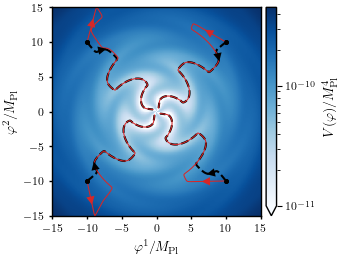

In [597]:
#  Potential colormap and trajectories for non-linear potential

# Parameters
half_square_side   = 15
phi1_min, phi1_max = -half_square_side, half_square_side
phi2_min, phi2_max = -half_square_side, half_square_side
width              = 8.6
aspect             = 1.3
colormap           = "Blues"
ntrajs             = 8

# Load data
potential = np.loadtxt(f'potential_MVP.txt')
ngrid = potential.shape[0]

# Coordinate axes
phi1   = np.linspace(phi1_min, phi1_max, ngrid)
phi2   = np.linspace(phi2_min, phi2_max, ngrid)
extent = [phi1_min, phi1_max, phi2_min, phi2_max]

# Create figure
fig = plt.figure(figsize=(cm2inch(width), cm2inch(width/aspect)))
ax = fig.add_axes([0.05, 0.17, 0.80, 0.80])  # [left, bottom, width, height]
ax.set_box_aspect(1)

# Plot
im = ax.imshow(potential, origin='lower', extent=extent, aspect='auto', cmap=colormap, interpolation='none', norm=mcolors.LogNorm(vmin=1E-11), alpha=1.0)
# im = ax.imshow(potential, origin='lower', extent=extent, aspect='auto', cmap=colormap, interpolation='none')

# Tell Matplotlib not to epand the data limits when drawing arrows
ax.autoscale(False)

# Plot trajectories with GBM field-space metric
for i in [1,2,7,8]:
    traj = np.loadtxt(f"trajs_EUM_MVP/traj_{i}.txt")

    # Find where column 5 reaches 1.0
    # idx = np.argmax(traj[:, 4] >= 1.0)
    
    ax.plot(traj[:, 0], traj[:, 1], linestyle='--', color='black', lw=1.5, alpha=1.0)
    ax.plot(traj[0, 0], traj[0, 1], 'o', color='black', markersize=2.5, alpha=1.0)
    # ax.plot(traj[idx, 0], traj[idx, 1], 'o', color='salmon', markersize=1.5, alpha=1.0)
    arrowhead(ax, traj[: , :2], d=3.0, c='black', hw=1.25, hl=1.50)

for i in [1,2,7,8]:
    traj = np.loadtxt(f"trajs_EUM_MVP_1/traj_{i}.txt")

    # Find where column 5 reaches 1.0
    # idx = np.argmax(traj[:, 4] >= 1.0)
    
    ax.plot(traj[:, 0], traj[:, 1], linestyle='-', color='tab:red', lw=0.75, alpha=1.0)
    ax.plot(traj[0, 0], traj[0, 1], 'o', color='black', markersize=2.5, alpha=1.0)
    # ax.plot(traj[idx, 0], traj[idx, 1], 'o', color='salmon', markersize=1.5, alpha=1.0)
    arrowhead(ax, traj[: , :2], d=3.0, c='tab:red', hw=1.25, hl=1.50)

# =============================================================================
# Axis formatting
# =============================================================================
# ax.set_title(fr'$\alpha = \beta = 1$', fontsize=10)
ax.set_xlabel(r'$\varphi^1 / M_{\mathrm{Pl}}$', fontsize=10)
ax.set_ylabel(r'$\varphi^2 / M_{\mathrm{Pl}}$', fontsize=10)
# ax.tick_params(axis='both', which='major', labelsize=10, length=2.5, width=1, pad=8)
ax.tick_params(axis='both', which='major', labelsize=8, length=2.5, width=1)

# =============================================================================
# Colorbar
# =============================================================================
cbar = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.08, shrink=1, extend="min")
cbar.set_label(r'$V(\varphi) / M_{\mathrm{Pl}}^{4}$', fontsize=10)
cbar.ax.tick_params(labelsize=8)

# Save to PDF
plt.savefig(f'trajs_8IC_EUM_MVP.pdf')

## 3D potential - Helix trajectory potential

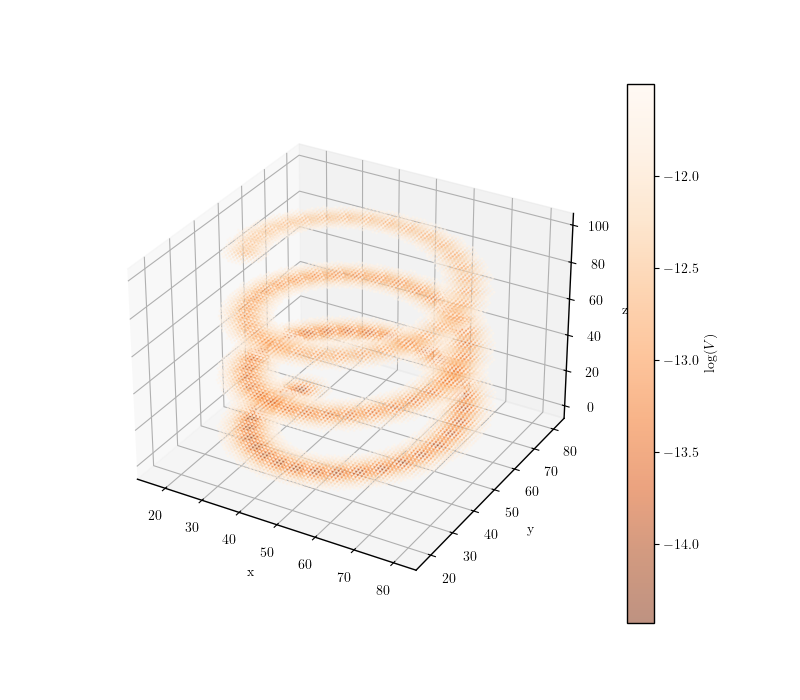

In [68]:
ngrid = 100
N = 100   # number of points per dimension to plot

filename = "potential_data_3f_HTP.txt"
data = np.loadtxt(filename)

i = data[:,0].astype(int) - 1
j = data[:,1].astype(int) - 1
k = data[:,2].astype(int) - 1
v = data[:,3]

# reconstruct cube
V = np.zeros((ngrid,ngrid,ngrid))
V[i,j,k] = v

# safe log
logV = np.log(V)

# uniform indices
idx = np.linspace(0, ngrid-1, N).astype(int)

# build point list
xs, ys, zs, cs = [], [], [], []

for a in idx:
    for b in idx:
        for c in idx:
            xs.append(a)
            ys.append(b)
            zs.append(c)
            cs.append(logV[a,b,c])

xs = np.array(xs)
ys = np.array(ys)
zs = np.array(zs)
cs = np.array(cs)

threshold = -11.5

mask = cs < threshold

xs = xs[mask]
ys = ys[mask]
zs = zs[mask]
cs = cs[mask]

# plot
fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection='3d')

p = ax.scatter(xs, ys, zs,
               c=cs,
               cmap='Oranges_r',
               s=1, alpha=0.5)

fig.colorbar(p, ax=ax, label=r"$\log(V)$")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()